In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Advanced Models
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ Install XGBoost: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ Install LightGBM: pip install lightgbm")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports complete!")
print(f"📊 XGBoost: {XGBOOST_AVAILABLE} | LightGBM: {LIGHTGBM_AVAILABLE}")

✅ Imports complete!
📊 XGBoost: True | LightGBM: True


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(df.head())
print("\n" + "="*70)
print(df.info())

DATASET OVERVIEW
Shape: 7043 rows × 21 columns

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport 

In [3]:
print("DATA QUALITY CHECKS")
print("="*70)
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Fix TotalCharges (it's stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nNon-numeric TotalCharges: {df['TotalCharges'].isna().sum()}")

# Show problematic rows
if df['TotalCharges'].isna().sum() > 0:
    print("\nSample problematic rows:")
    print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

DATA QUALITY CHECKS
Duplicates: 0
Missing values:
Series([], dtype: int64)

Non-numeric TotalCharges: 11

Sample problematic rows:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN



CHURN DISTRIBUTION
No:  5,174 (73.5%)
Yes: 1,869 (26.5%)

Churn Rate: 26.54%


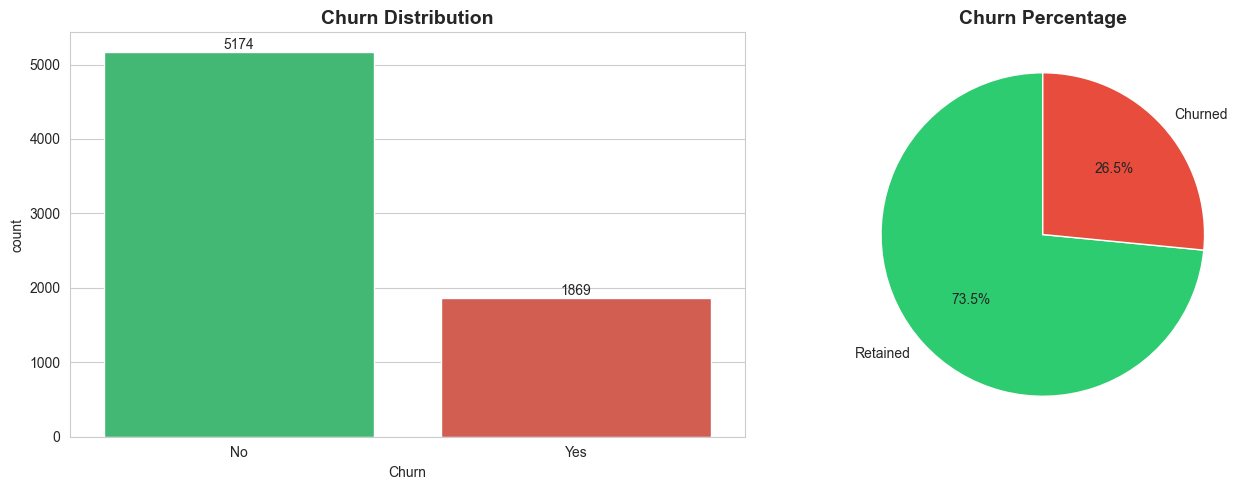

In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct = churn_counts / len(df) * 100

print("\nCHURN DISTRIBUTION")
print("="*70)
print(f"No:  {churn_counts['No']:,} ({churn_pct['No']:.1f}%)")
print(f"Yes: {churn_counts['Yes']:,} ({churn_pct['Yes']:.1f}%)")
print(f"\nChurn Rate: {churn_pct['Yes']:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

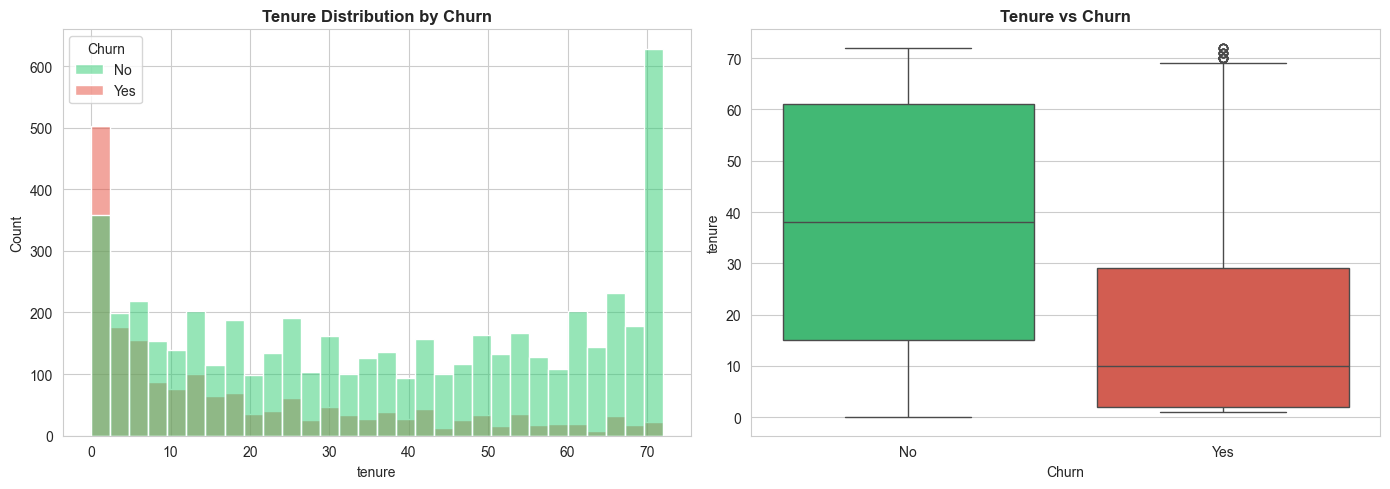

Tenure Stats:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


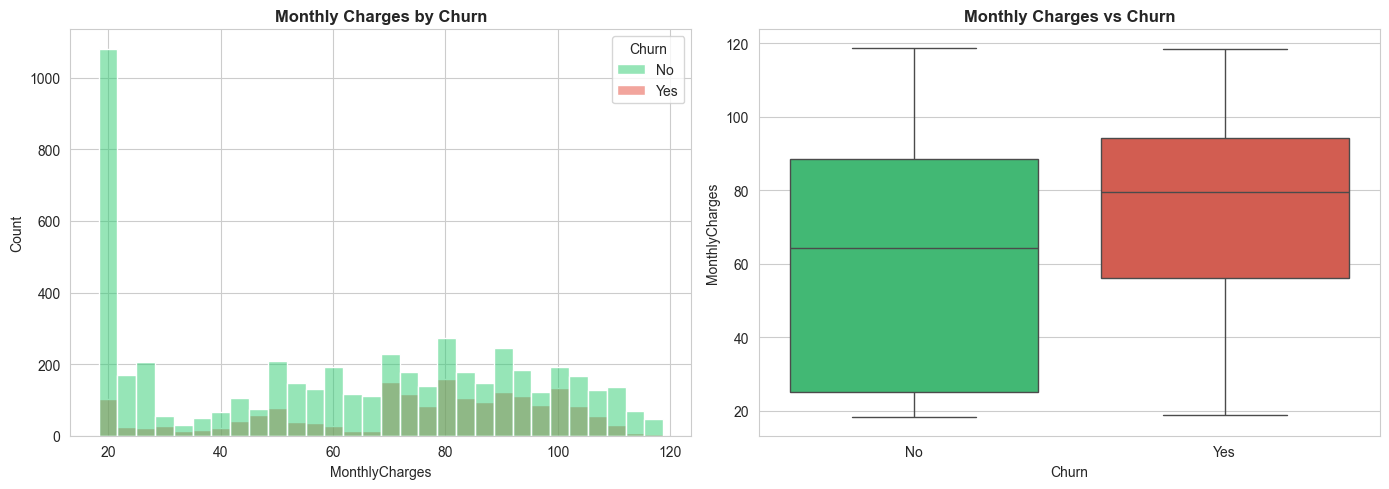

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Tenure vs Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tenure Stats:")
print(df.groupby('Churn')['tenure'].describe())

# Monthly Charges Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Monthly Charges by Churn', fontsize=12, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', 
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

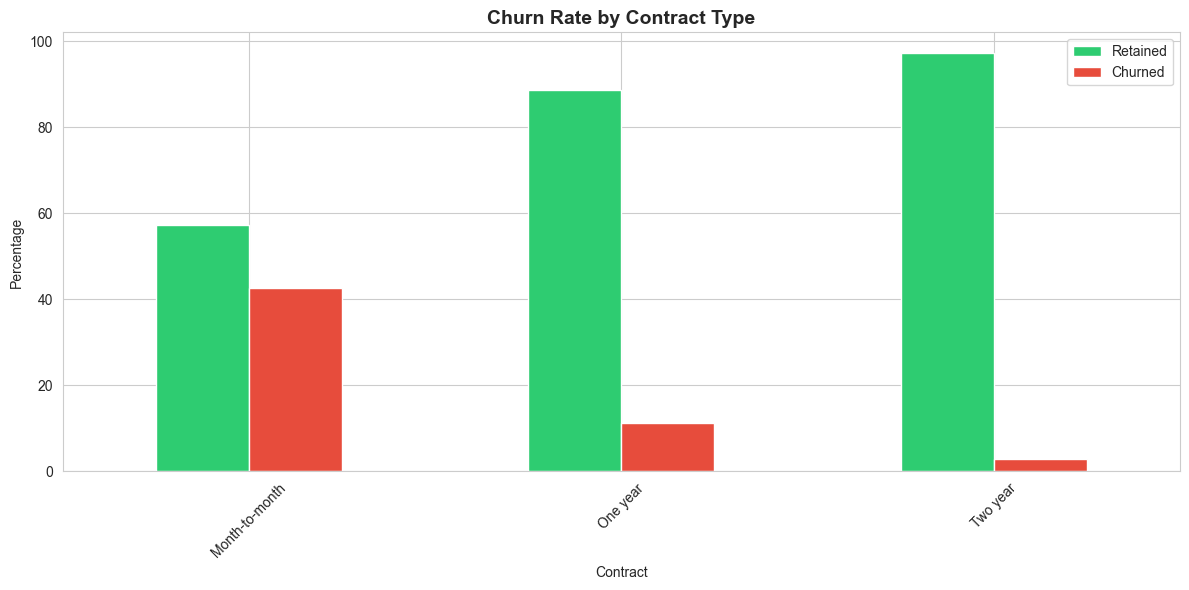

Churn % by Contract:
 Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


<Figure size 1000x500 with 0 Axes>

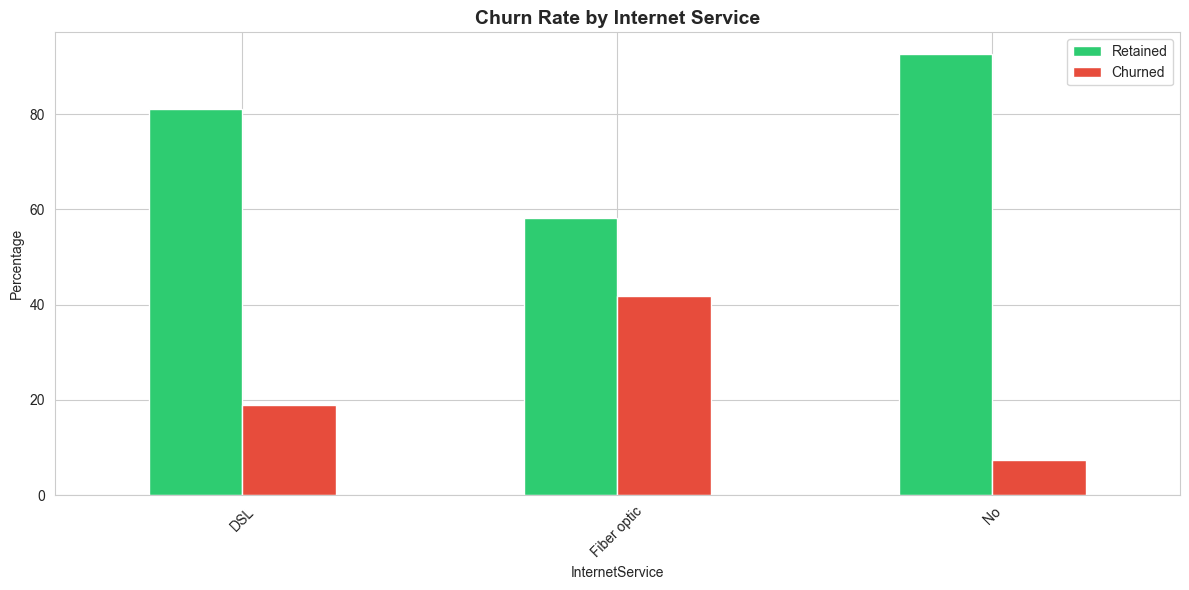

<Figure size 1200x500 with 0 Axes>

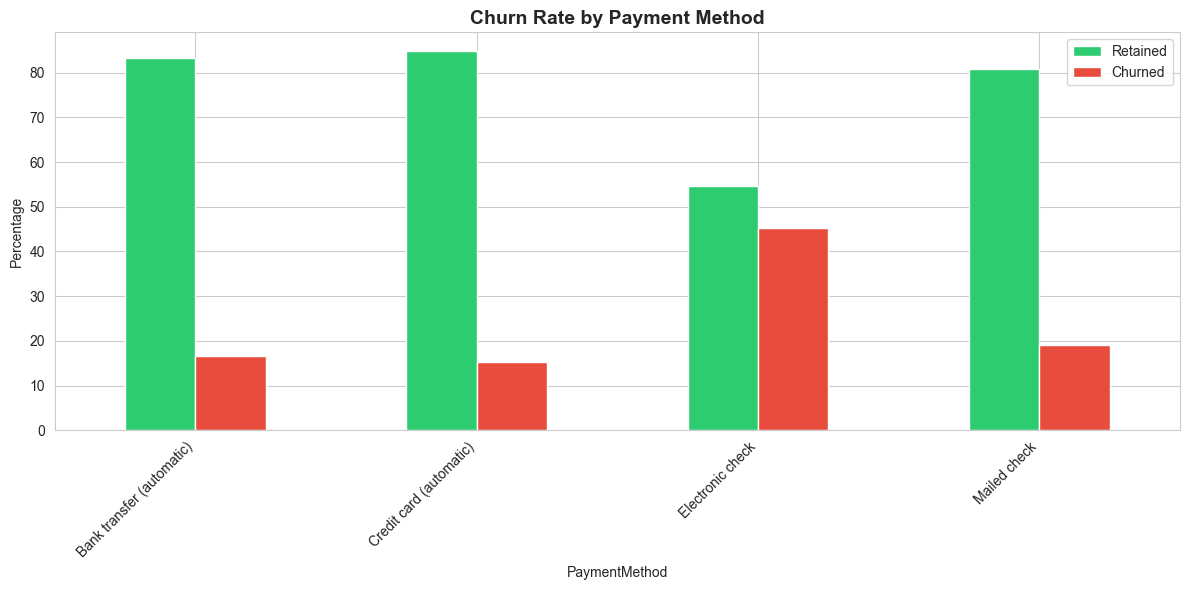

In [6]:
plt.figure(figsize=(10, 5))
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()
print("Churn % by Contract:\n", contract_churn.round(1))

# Internet Service
plt.figure(figsize=(10, 5))
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

# Payment Method
plt.figure(figsize=(12, 5))
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

In [7]:
df_processed = df.copy()

# Handle missing TotalCharges
df_processed['TotalCharges'].fillna(
    df_processed['tenure'] * df_processed['MonthlyCharges'], 
    inplace=True
)

# Drop customerID
df_processed.drop('customerID', axis=1, inplace=True)

# Convert SeniorCitizen to Yes/No
df_processed['SeniorCitizen'] = df_processed['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("✅ Basic preprocessing complete")
print(f"Shape: {df_processed.shape}")

✅ Basic preprocessing complete
Shape: (7043, 20)


FEATURE ENGINEERING
✅ Created 5 new features:
   • TenureGroup
   • TotalServices
   • AvgSpendPerService
   • ContractScore
   • HasAutoPayment

Correlation with Churn:
ContractScore        -0.396713
tenure               -0.352229
TotalCharges         -0.198324
TotalServices        -0.085963
MonthlyCharges        0.193356
AvgSpendPerService    0.399614
Name: Churn_Numeric, dtype: float64


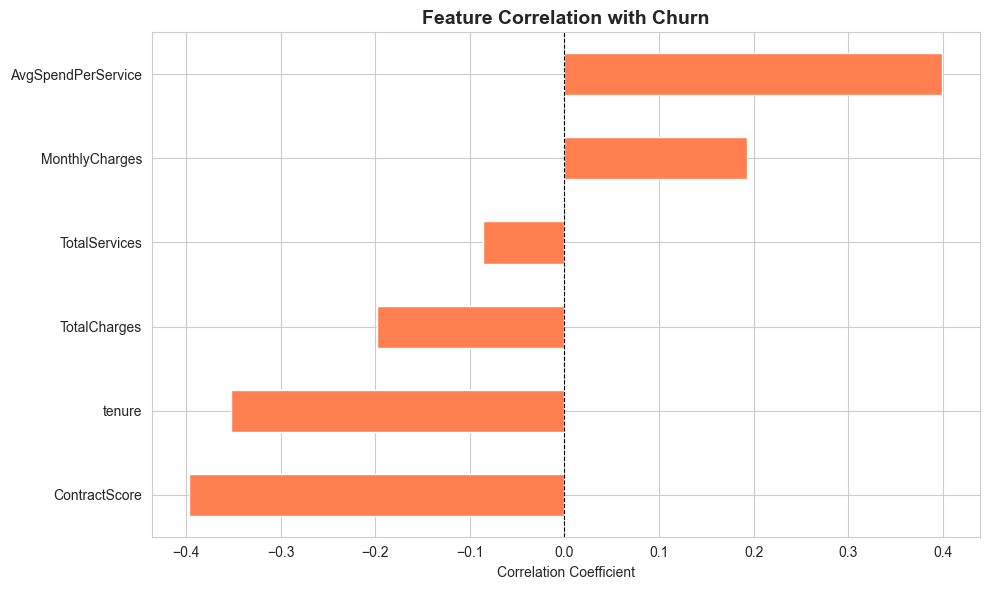

In [8]:
print("FEATURE ENGINEERING")
print("="*70)

# Tenure Categories
df_processed['TenureGroup'] = pd.cut(
    df_processed['tenure'],
    bins=[0, 12, 24, 60, 100],
    labels=['0-1yr', '1-2yr', '2-5yr', '5+yr']
)

# Total Services Count
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df_processed['TotalServices'] = (df_processed[service_cols] == 'Yes').sum(axis=1)

# Monthly Spend per Service
df_processed['AvgSpendPerService'] = df_processed['MonthlyCharges'] / (df_processed['TotalServices'] + 1)

# Contract Commitment Score
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df_processed['ContractScore'] = df_processed['Contract'].map(contract_map)

# Auto Payment Flag
df_processed['HasAutoPayment'] = df_processed['PaymentMethod'].apply(
    lambda x: 'Yes' if 'automatic' in x.lower() else 'No'
)

print("✅ Created 5 new features:")
print("   • TenureGroup")
print("   • TotalServices")
print("   • AvgSpendPerService")
print("   • ContractScore")
print("   • HasAutoPayment")

# Show correlation with churn
df_temp = df_processed.copy()
df_temp['Churn_Numeric'] = (df_temp['Churn'] == 'Yes').astype(int)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices',
                'AvgSpendPerService', 'ContractScore']
corr_with_churn = df_temp[numeric_cols + ['Churn_Numeric']].corr()['Churn_Numeric'].drop('Churn_Numeric').sort_values()

print("\nCorrelation with Churn:")
print(corr_with_churn)

plt.figure(figsize=(10, 6))
corr_with_churn.plot(kind='barh', color='coral')
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


In [9]:
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn'].map({'No': 0, 'Yes': 1})

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"Churn rate: {y.mean():.2%}")

# One-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nAfter encoding: {X_encoded.shape[1]} features")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

# Scale numerical features
scaler = StandardScaler()
numerical_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("✅ Data ready for modeling")

Features: (7043, 24)
Target: (7043,)
Churn rate: 26.54%

After encoding: 37 features

Train: 5634 | Test: 1409
Train churn rate: 26.54%
Test churn rate: 26.54%
✅ Data ready for modeling


In [10]:
print("TRAINING MODELS")
print("="*70)

models = {}

# Logistic Regression
print("[1/4] Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
print("✅ Done")

# Random Forest
print("\n[2/4] Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf
print("✅ Done")

# XGBoost
if XGBOOST_AVAILABLE:
    print("\n[3/4] XGBoost...")
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, random_state=42,
        use_label_encoder=False, eval_metric='logloss'
    )
    xgb_model.fit(X_train_scaled, y_train)
    models['XGBoost'] = xgb_model
    print("✅ Done")
else:
    print("\n[3/4] ⚠️ XGBoost not available")

# LightGBM
if LIGHTGBM_AVAILABLE:
    print("\n[4/4] LightGBM...")
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        class_weight='balanced', random_state=42, verbose=-1
    )
    lgb_model.fit(X_train_scaled, y_train)
    models['LightGBM'] = lgb_model
    print("✅ Done")
else:
    print("\n[4/4] ⚠️ LightGBM not available")

print(f"\n🎉 {len(models)} models trained successfully!")

TRAINING MODELS
[1/4] Logistic Regression...
✅ Done

[2/4] Random Forest...
✅ Done

[3/4] XGBoost...
✅ Done

[4/4] LightGBM...
✅ Done

🎉 4 models trained successfully!


In [11]:
print("MODEL EVALUATION")
print("="*70)

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1-Score:  {results[name]['f1_score']:.4f}")
    print(f"  ROC-AUC:   {results[name]['roc_auc']:.4f}")

# Comparison table
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']].round(4)
print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(comparison_df)

best_model_name = comparison_df['roc_auc'].idxmax()
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {comparison_df.loc[best_model_name, 'roc_auc']:.4f})")

MODEL EVALUATION

Logistic Regression:
  Accuracy:  0.7395
  Precision: 0.5060
  Recall:    0.7941
  F1-Score:  0.6181
  ROC-AUC:   0.8417

Random Forest:
  Accuracy:  0.7665
  Precision: 0.5451
  Recall:    0.7273
  F1-Score:  0.6231
  ROC-AUC:   0.8395

XGBoost:
  Accuracy:  0.7622
  Precision: 0.5377
  Recall:    0.7433
  F1-Score:  0.6240
  ROC-AUC:   0.8382

LightGBM:
  Accuracy:  0.7544
  Precision: 0.5260
  Recall:    0.7567
  F1-Score:  0.6206
  ROC-AUC:   0.8352

COMPARISON TABLE
                     accuracy precision    recall  f1_score   roc_auc
Logistic Regression  0.739532  0.505963  0.794118  0.618106  0.841737
Random Forest        0.766501   0.54509  0.727273  0.623139  0.839461
XGBoost              0.762243  0.537718  0.743316  0.624018  0.838193
LightGBM             0.754436  0.526022  0.756684  0.620614  0.835166

🏆 Best Model: Logistic Regression (ROC-AUC: 0.8417)


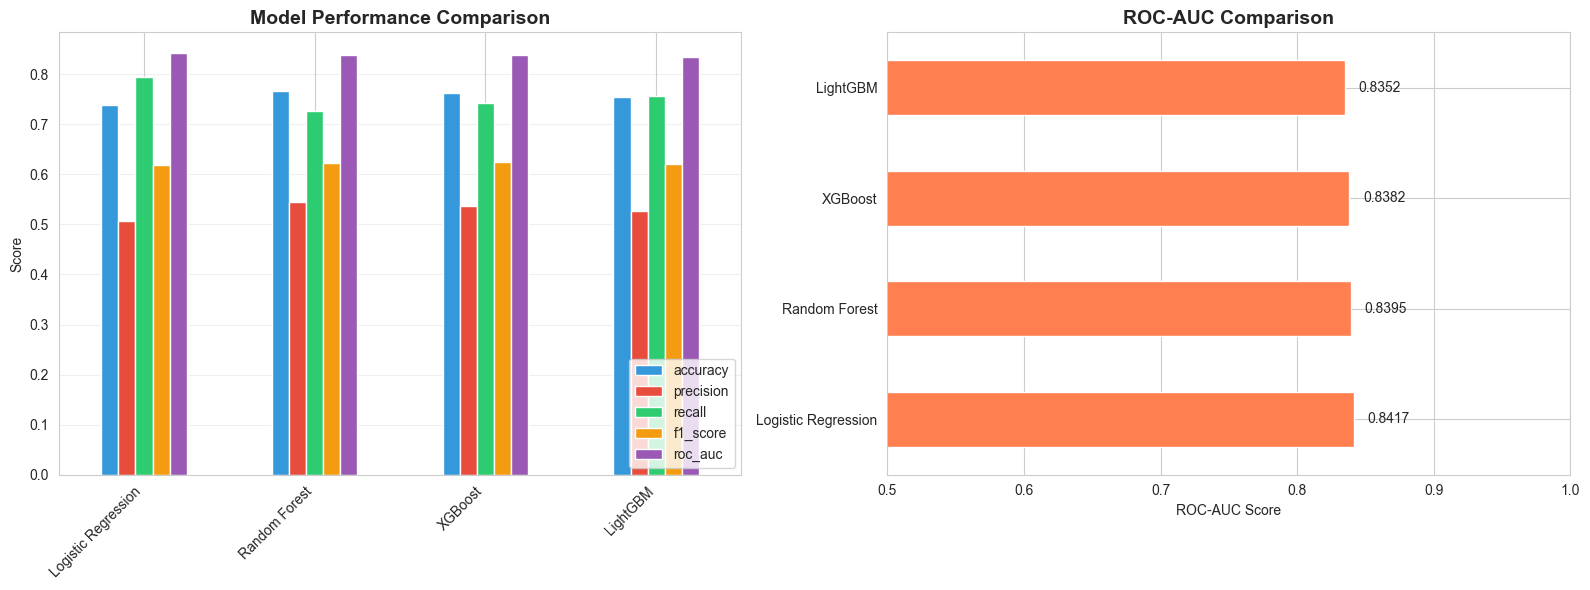

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All metrics
comparison_df.plot(kind='bar', ax=axes[0], 
                   color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC focus
comparison_df['roc_auc'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_xlim([0.5, 1.0])
for i, v in enumerate(comparison_df['roc_auc']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

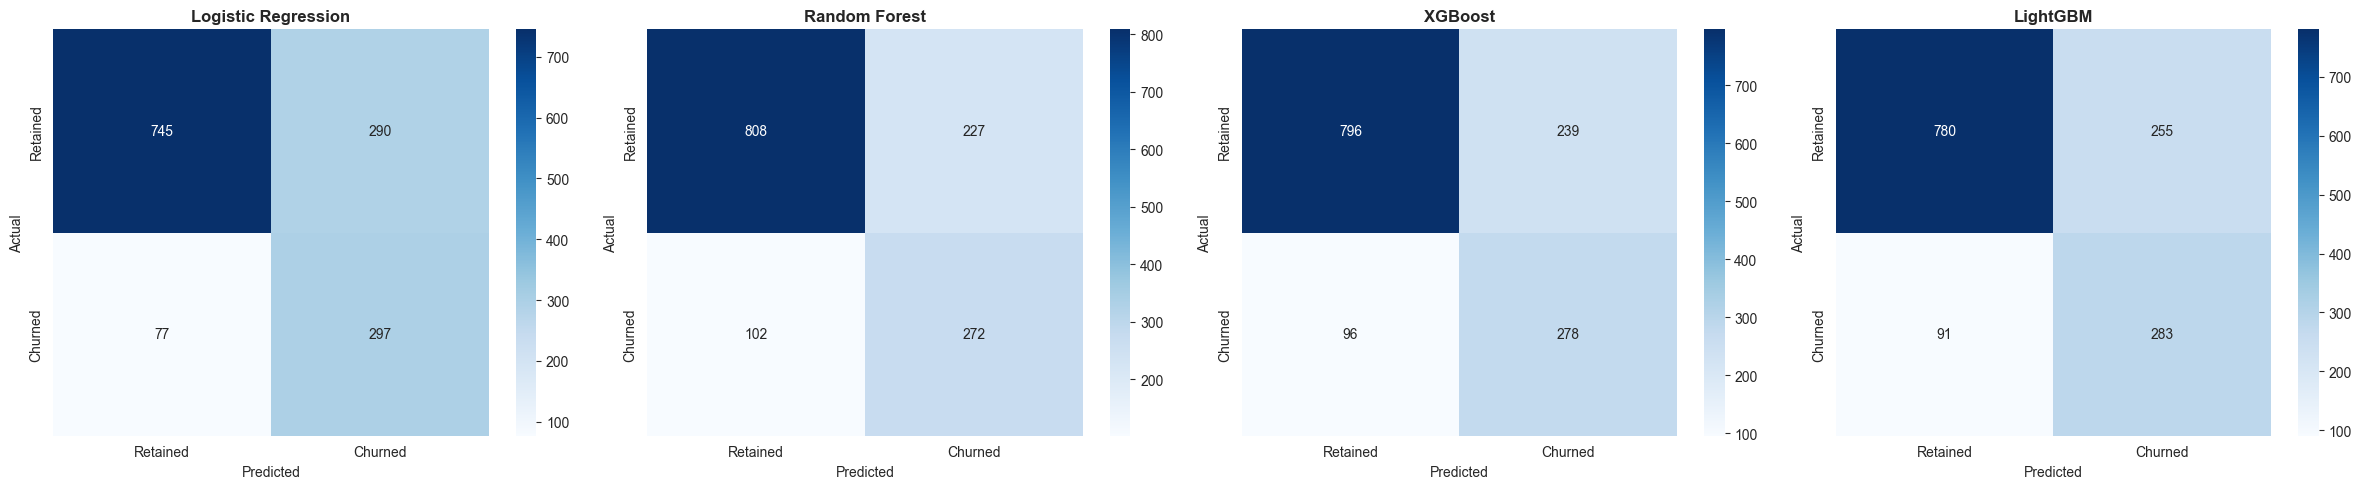


Logistic Regression - Confusion Matrix:
True Negatives:  745 (Correctly predicted Retained)
False Positives: 290 (False alarms)
False Negatives: 77 (Missed churners)
True Positives:  297 (Correctly predicted Churned)

Recall: 79.4% (caught 297 out of 374 churners)


In [13]:
fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
if len(models) == 1:
    axes = [axes]

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Best model breakdown
best_cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
tn, fp, fn, tp = best_cm.ravel()
print(f"\n{best_model_name} - Confusion Matrix:")
print(f"True Negatives:  {tn} (Correctly predicted Retained)")
print(f"False Positives: {fp} (False alarms)")
print(f"False Negatives: {fn} (Missed churners)")
print(f"True Positives:  {tp} (Correctly predicted Churned)")
print(f"\nRecall: {tp/(tp+fn)*100:.1f}% (caught {tp} out of {tp+fn} churners)")


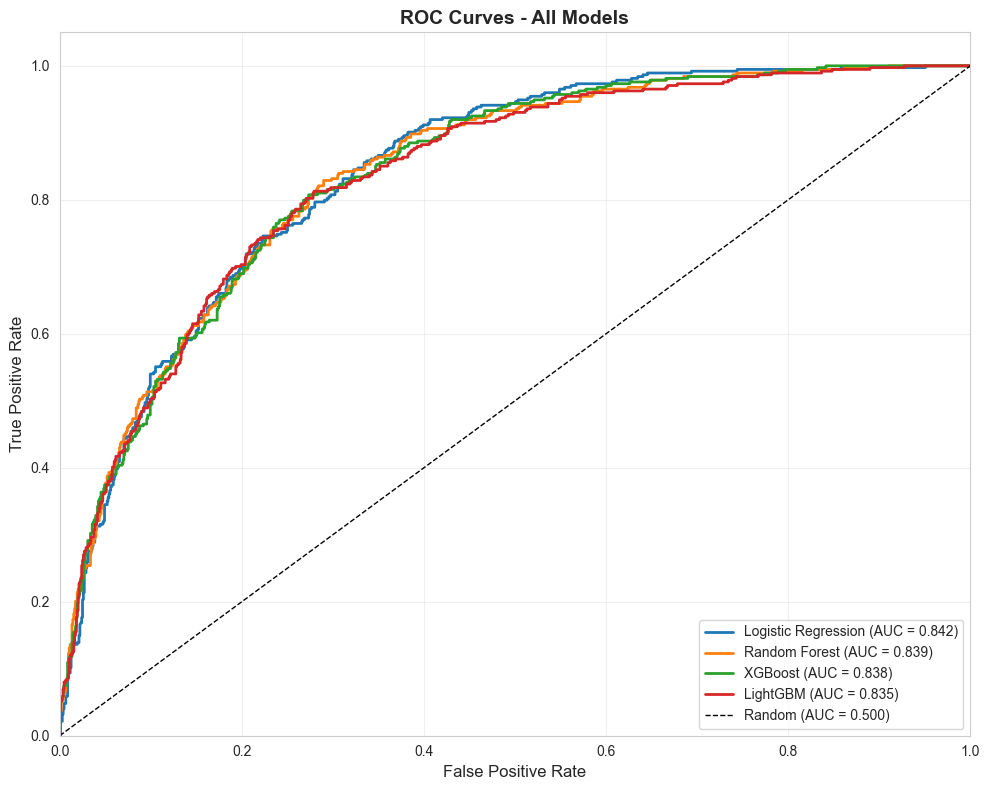

In [14]:
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, linewidth=2, 
             label=f'{name} (AUC = {result["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

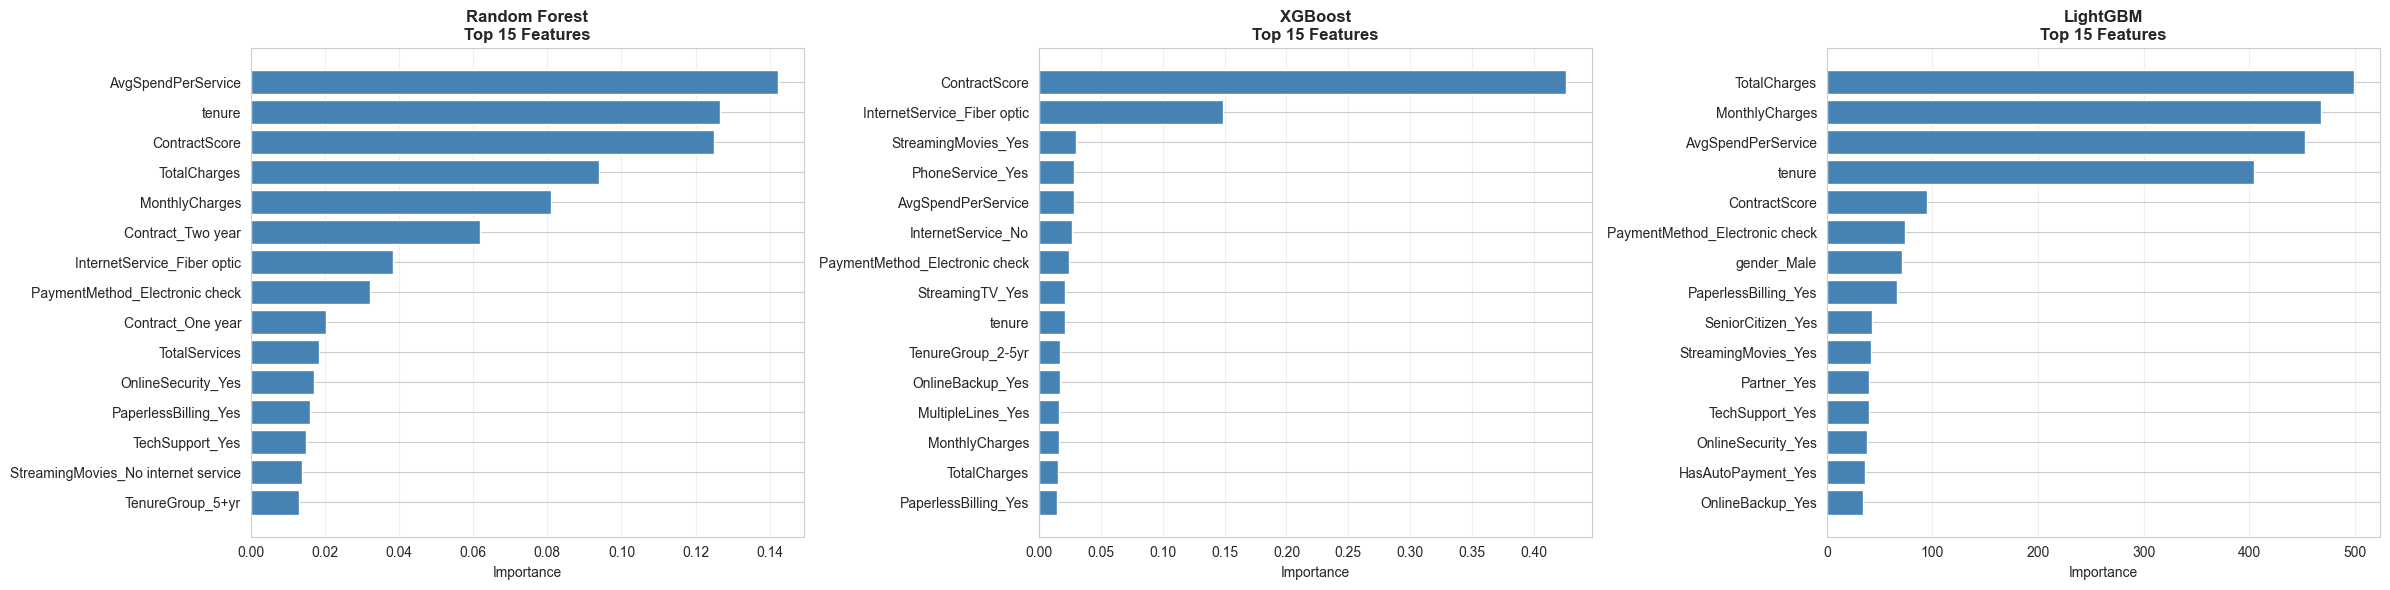

In [15]:
feature_imp_models = {}
if 'Random Forest' in models:
    feature_imp_models['Random Forest'] = models['Random Forest'].feature_importances_
if 'XGBoost' in models:
    feature_imp_models['XGBoost'] = models['XGBoost'].feature_importances_
if 'LightGBM' in models:
    feature_imp_models['LightGBM'] = models['LightGBM'].feature_importances_

if len(feature_imp_models) > 0:
    num_models = len(feature_imp_models)
    fig, axes = plt.subplots(1, num_models, figsize=(8*num_models, 6))
    if num_models == 1:
        axes = [axes]
    
    for idx, (name, importances) in enumerate(feature_imp_models.items()):
        imp_df = pd.DataFrame({
            'feature': X_encoded.columns,
            'importance': importances
        }).sort_values('importance', ascending=False).head(15)
        
        axes[idx].barh(range(len(imp_df)), imp_df['importance'], color='steelblue')
        axes[idx].set_yticks(range(len(imp_df)))
        axes[idx].set_yticklabels(imp_df['feature'])
        axes[idx].invert_yaxis()
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'{name}\nTop 15 Features', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    if best_model_name in feature_imp_models:
        print(f"\n{best_model_name} - Top 10 Features:")
        top_feat = pd.DataFrame({
            'feature': X_encoded.columns,
            'importance': feature_imp_models[best_model_name]
        }).sort_values('importance', ascending=False).head(10)
        print(top_feat.to_string(index=False))

CUSTOMER RISK SEGMENTATION

Risk Distribution:
Risk_Category
Low Risk       602
Medium Risk    330
High Risk      477
Name: count, dtype: int64

Actual Churn Rate by Risk:
               Churn Rate (%)  Count
Risk_Category                       
Low Risk             4.817276    602
Medium Risk         23.939394    330
High Risk           55.765199    477


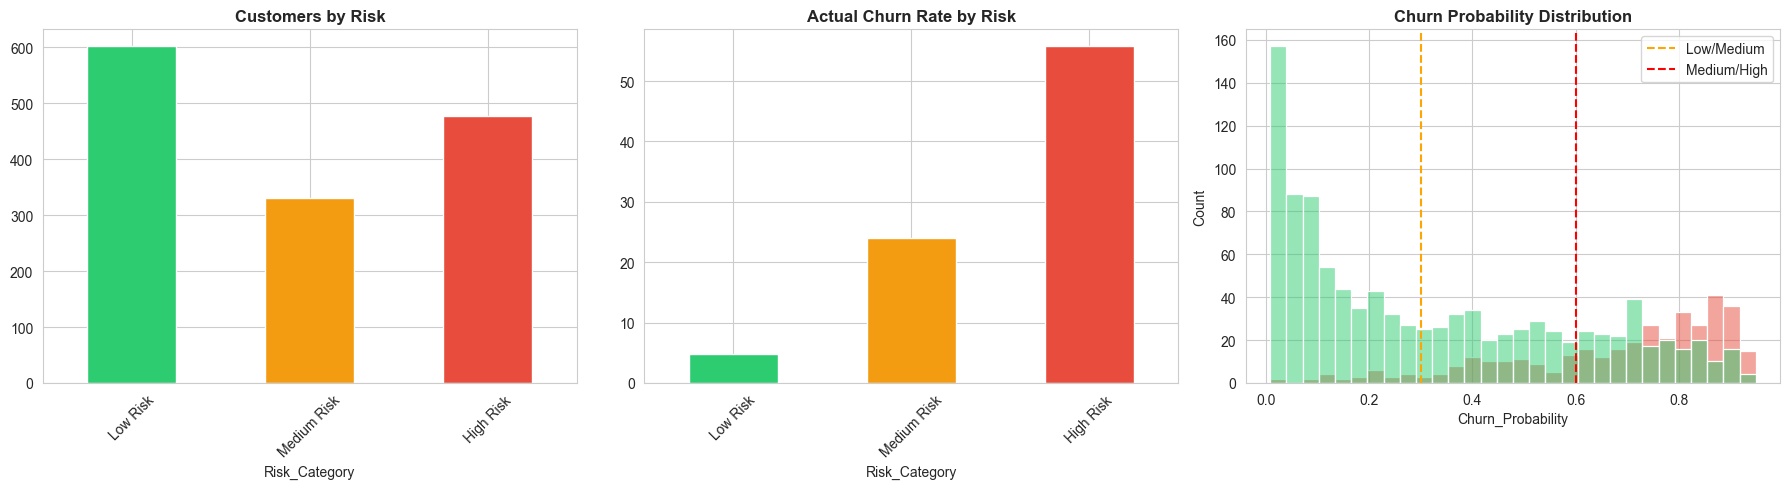

In [16]:
best_model = models[best_model_name]
churn_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

risk_categories = pd.cut(
    churn_probabilities,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_df = pd.DataFrame({
    'Churn_Probability': churn_probabilities,
    'Risk_Category': risk_categories,
    'Actual_Churn': y_test.values
})

print("CUSTOMER RISK SEGMENTATION")
print("="*70)
print("\nRisk Distribution:")
print(risk_df['Risk_Category'].value_counts().sort_index())

print("\nActual Churn Rate by Risk:")
churn_by_risk = risk_df.groupby('Risk_Category')['Actual_Churn'].agg(['mean', 'count'])
churn_by_risk['mean'] = churn_by_risk['mean'] * 100
churn_by_risk.columns = ['Churn Rate (%)', 'Count']
print(churn_by_risk)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risk distribution
risk_df['Risk_Category'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[0].set_title('Customers by Risk', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Churn rate by risk
churn_by_risk['Churn Rate (%)'].plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[1].set_title('Actual Churn Rate by Risk', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# Probability distribution
sns.histplot(data=risk_df, x='Churn_Probability', hue='Actual_Churn',
             bins=30, ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Churn Probability Distribution', fontsize=12, fontweight='bold')
axes[2].axvline(x=0.3, color='orange', linestyle='--', label='Low/Medium')
axes[2].axvline(x=0.6, color='red', linestyle='--', label='Medium/High')
axes[2].legend()

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*70)

# High risk customers
high_risk_count = (risk_df['Risk_Category'] == 'High Risk').sum()
high_risk_actual_churn = risk_df[risk_df['Risk_Category'] == 'High Risk']['Actual_Churn'].mean()

print(f"\n📊 KEY METRICS:")
print(f"• Total test customers: {len(risk_df):,}")
print(f"• High-risk customers: {high_risk_count} ({high_risk_count/len(risk_df)*100:.1f}%)")
print(f"• Actual churn in high-risk: {high_risk_actual_churn*100:.1f}%")
print(f"• Model accuracy: {results[best_model_name]['accuracy']*100:.1f}%")
print(f"• Model ROC-AUC: {results[best_model_name]['roc_auc']:.3f}")

print(f"\n💡 TOP CHURN DRIVERS (from feature importance):")
if best_model_name in feature_imp_models:
    top_5 = pd.DataFrame({
        'feature': X_encoded.columns,
        'importance': feature_imp_models[best_model_name]
    }).sort_values('importance', ascending=False).head(5)
    for i, row in top_5.iterrows():
        print(f"   {row['feature']}")

print(f"\n🎯 RECOMMENDATIONS:")
print("1. IMMEDIATE ACTION - High Risk Customers:")
print(f"   • Target {high_risk_count} high-risk customers with retention campaigns")
print("   • Offer contract upgrades (month-to-month → annual)")
print("   • Provide personalized discounts or added services")

print("\n2. PREVENTIVE MEASURES - New Customers:")
print("   • Strengthen onboarding for customers in first 12 months")
print("   • Incentivize long-term contracts at sign-up")
print("   • Improve customer support touchpoints early")

print("\n3. PRODUCT IMPROVEMENTS:")
print("   • Investigate fiber optic service quality issues")
print("   • Promote automatic payment adoption")
print("   • Bundle services to increase engagement")

print("\n4. MONITORING:")
print("   • Monthly re-scoring of all customers")
print("   • Track intervention success rate")
print("   • A/B test retention strategies")

# ROI Calculation
avg_customer_value = 50  # Assume $50/month average
retention_cost = 20  # Assume $20 to retain one customer
success_rate = 0.3  # 30% of interventions successful

prevented_churners = high_risk_count * high_risk_actual_churn * success_rate
revenue_saved = prevented_churners * avg_customer_value * 12  # Annual value
intervention_cost = high_risk_count * retention_cost
net_benefit = revenue_saved - intervention_cost

print(f"\n💰 ESTIMATED ROI (Conservative):")
print(f"   • High-risk customers to target: {high_risk_count}")
print(f"   • Expected prevention (30% success): {prevented_churners:.0f} customers")
print(f"   • Annual revenue saved: ${revenue_saved:,.0f}")
print(f"   • Intervention cost: ${intervention_cost:,.0f}")
print(f"   • Net benefit: ${net_benefit:,.0f}")
print(f"   • ROI: {(net_benefit/intervention_cost)*100:.0f}%")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)



BUSINESS INSIGHTS & RECOMMENDATIONS

📊 KEY METRICS:
• Total test customers: 1,409
• High-risk customers: 477 (33.9%)
• Actual churn in high-risk: 55.8%
• Model accuracy: 74.0%
• Model ROC-AUC: 0.842

💡 TOP CHURN DRIVERS (from feature importance):

🎯 RECOMMENDATIONS:
1. IMMEDIATE ACTION - High Risk Customers:
   • Target 477 high-risk customers with retention campaigns
   • Offer contract upgrades (month-to-month → annual)
   • Provide personalized discounts or added services

2. PREVENTIVE MEASURES - New Customers:
   • Strengthen onboarding for customers in first 12 months
   • Incentivize long-term contracts at sign-up
   • Improve customer support touchpoints early

3. PRODUCT IMPROVEMENTS:
   • Investigate fiber optic service quality issues
   • Promote automatic payment adoption
   • Bundle services to increase engagement

4. MONITORING:
   • Monthly re-scoring of all customers
   • Track intervention success rate
   • A/B test retention strategies

💰 ESTIMATED ROI (Conservative)

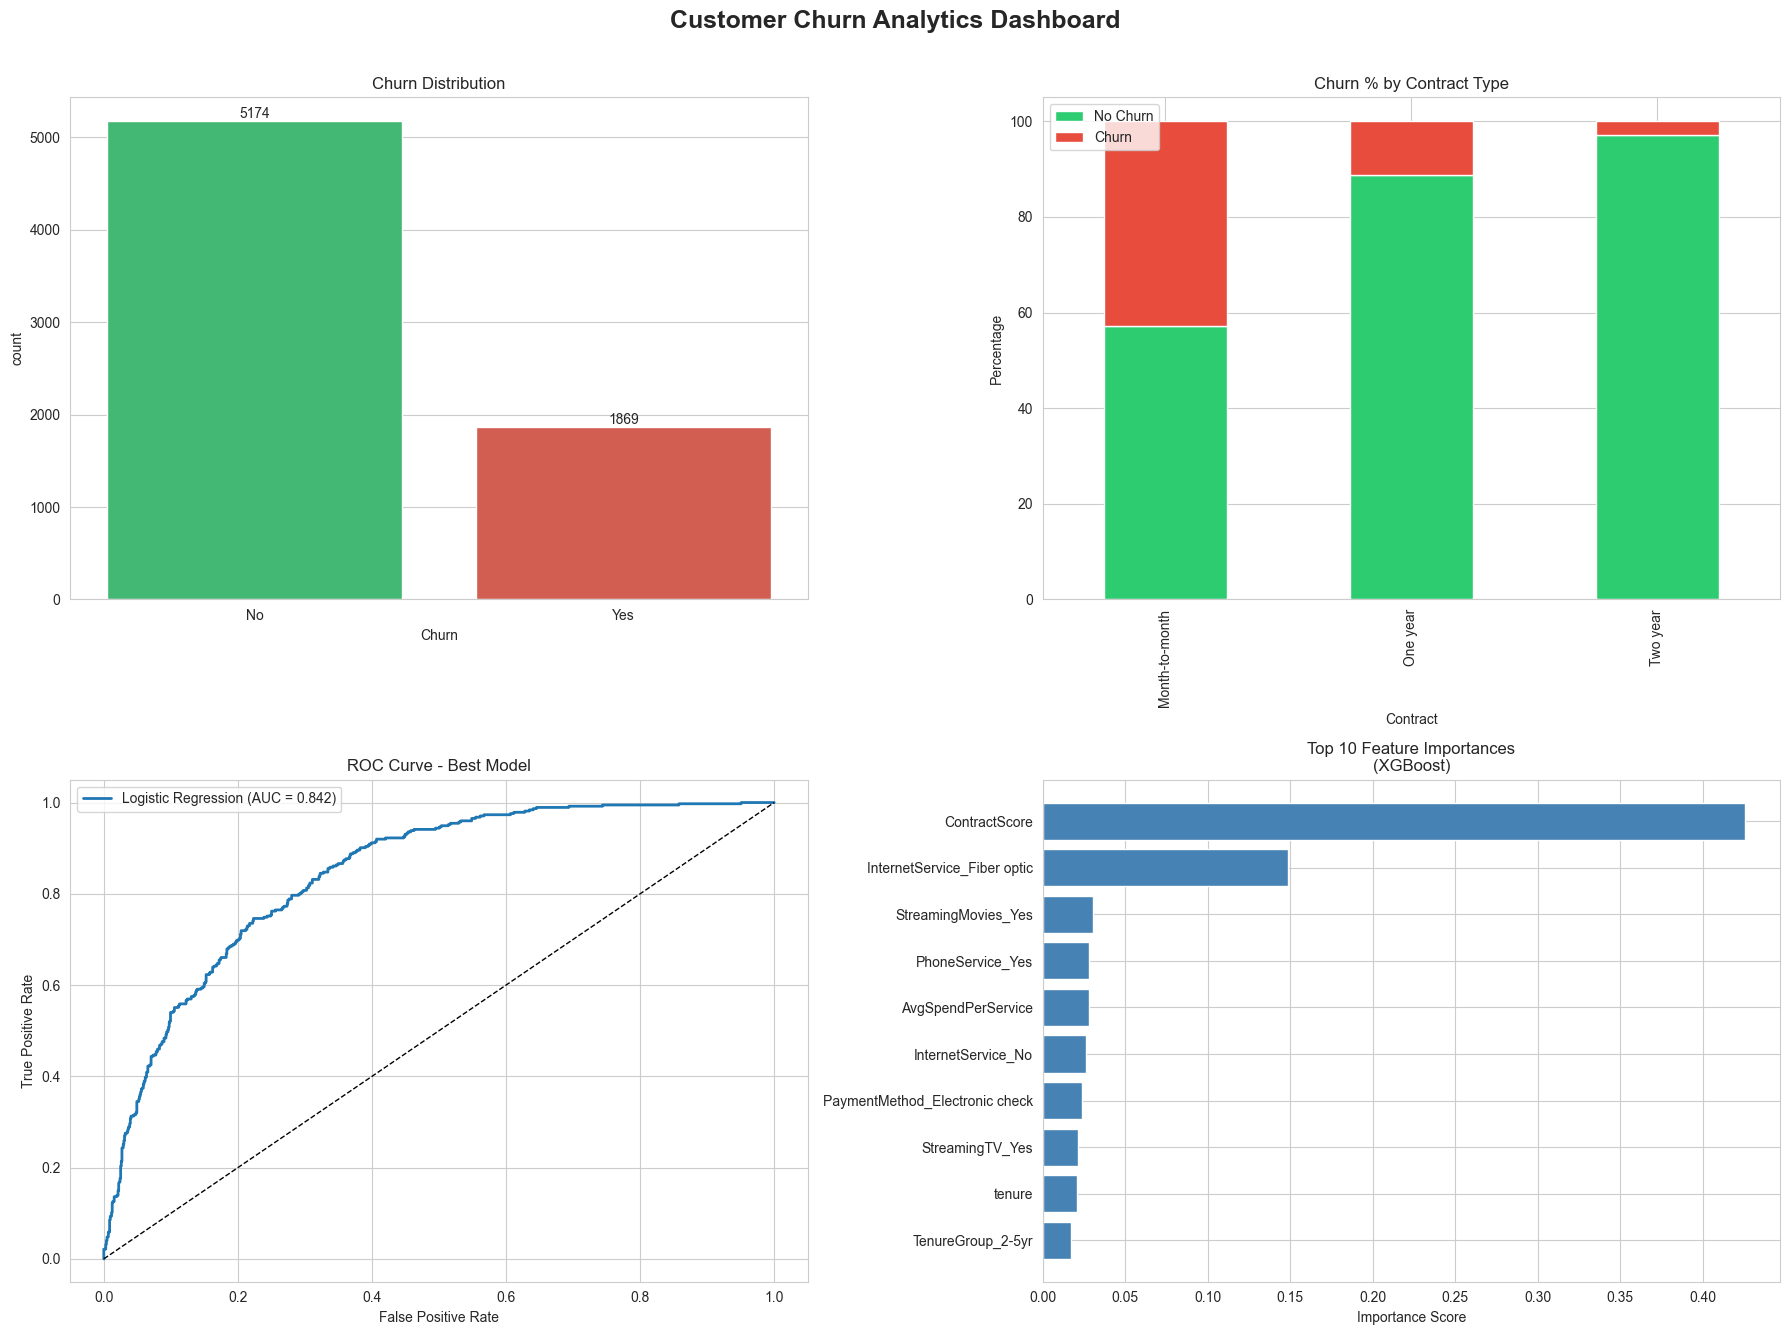

In [18]:
# ======================================================================
# FINAL BUSINESS DASHBOARD (MATPLOTLIB CONSOLIDATED VISUALS)
# ======================================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Customer Churn Analytics Dashboard", fontsize=18, fontweight='bold')

# ------------------------ 1. Churn Distribution ------------------------
ax1 = fig.add_subplot(2, 2, 1)
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title("Churn Distribution")
for container in ax1.containers:
    ax1.bar_label(container)

# ------------------------ 2. Churn by Contract ------------------------
ax2 = fig.add_subplot(2, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, ax=ax2,
                    color=['#2ecc71', '#e74c3c'])
ax2.set_title("Churn % by Contract Type")
ax2.set_ylabel("Percentage")
ax2.legend(["No Churn", "Churn"])

# ------------------------ 3. ROC Curve (Best Model) ------------------------
ax3 = fig.add_subplot(2, 2, 3)
fpr, tpr, _ = roc_curve(y_test, results[best_model_name]['y_pred_proba'])
ax3.plot(fpr, tpr, linewidth=2,
         label=f'{best_model_name} (AUC = {results[best_model_name]["roc_auc"]:.3f})')
ax3.plot([0,1], [0,1], 'k--', linewidth=1)
ax3.set_title("ROC Curve - Best Model")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()

# ------------------------ 4. Feature Importance (Auto-select available model) ------------------------
ax4 = fig.add_subplot(2, 2, 4)

# Determine which model to use for feature importance
importance_model_name = None
for m in ['XGBoost', 'LightGBM', 'Random Forest']:   # Preferred order
    if m in feature_imp_models:
        importance_model_name = m
        break

if importance_model_name is None:
    ax4.text(0.5, 0.5, "No model with feature importance available",
             ha='center', va='center', fontsize=12)
    ax4.set_title("Feature Importance")
else:
    imp_values = feature_imp_models[importance_model_name]
    imp_df = pd.DataFrame({
        'feature': X_encoded.columns,
        'importance': imp_values
    }).sort_values('importance', ascending=False).head(10)

    ax4.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax4.set_title(f"Top 10 Feature Importances\n({importance_model_name})")
    ax4.invert_yaxis()
    ax4.set_xlabel("Importance Score")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


<h1 style='color:#2c3e50;font-weight:bold;'>Telco Customer Churn Analytics Report</h1><p style='font-size:15px;color:#2c3e50;'>Prepared on: 17 December 2025</p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>1. Executive Summary</h2><p style='font-size:15px;color:#2c3e50;'>This report presents a comprehensive churn prediction system built using telecom customer data. The analysis includes predictive modeling, customer risk segmentation, feature importance, and high-impact business recommendations.</p><p style='font-size:15px;color:#2c3e50;'>The best performing model is <b>Logistic Regression</b> with a ROC-AUC score of <b>0.842</b>, demonstrating strong ability to identify customers with a high likelihood of churning.</p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>2. Customer Base Overview</h2><p style='margin-left:20px;color:#2c3e50;'>• Total customers analyzed: <b>7,043</b></p><p style='margin-left:20px;color:#2c3e50;'>• Churned customers: <b>1,869</b></p><p style='margin-left:20px;color:#2c3e50;'>• Retained customers: <b>5,174</b></p><p style='margin-left:20px;color:#2c3e50;'>• Overall churn rate: <b>26.54%</b></p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>3. Model Performance</h2><p style='font-size:15px;color:#2c3e50;'>The following metrics reflect the predictive strength of the best model:</p><p style='margin-left:20px;color:#2c3e50;'>• Accuracy: <b>0.7395</b></p><p style='margin-left:20px;color:#2c3e50;'>• Precision: <b>0.5060</b></p><p style='margin-left:20px;color:#2c3e50;'>• Recall: <b>0.7941</b></p><p style='margin-left:20px;color:#2c3e50;'>• F1 Score: <b>0.6181</b></p><p style='margin-left:20px;color:#2c3e50;'>• ROC-AUC Score: <b>0.8417</b></p><p style='font-size:15px;color:#2c3e50;'>Higher recall indicates the model reliably identifies churners, which is crucial for retention.</p><hr style='border:1px solid #ccc;margin:20px 0;'>

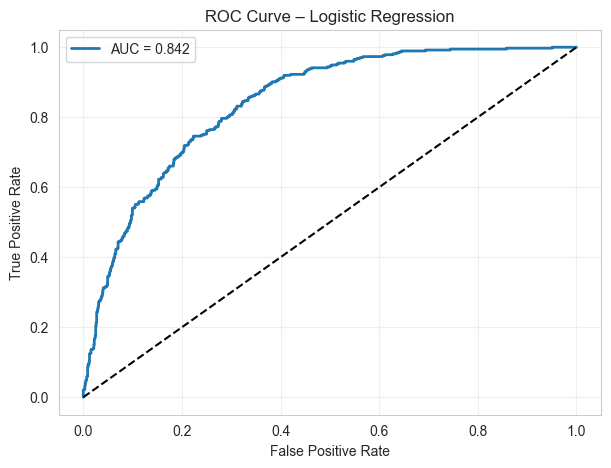

<hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>4. Key Drivers of Churn</h2><p style='font-size:15px;color:#2c3e50;'>Top features identified from <b>XGBoost</b>:</p>

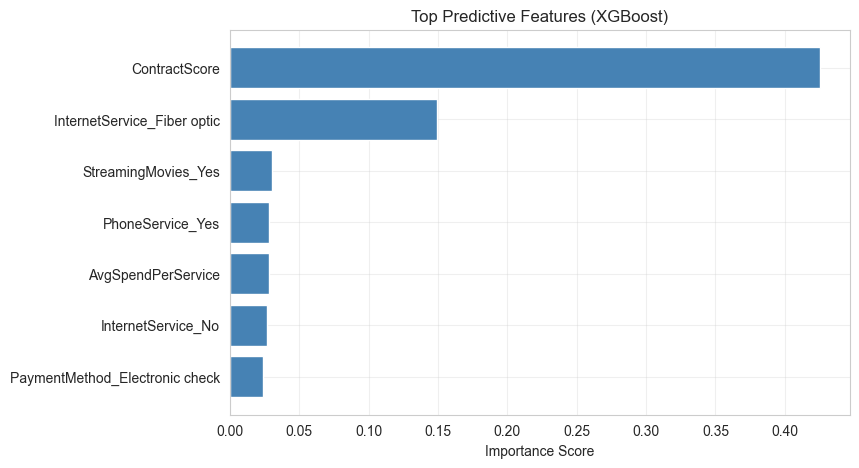

<hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>5. Customer Risk Segmentation</h2><p style='margin-left:20px;color:#2c3e50;'>• High-risk customers: <b>477</b></p><p style='margin-left:20px;color:#2c3e50;'>• Medium-risk customers: <b>330</b></p><p style='margin-left:20px;color:#2c3e50;'>• Low-risk customers: <b>602</b></p><p style='margin-left:20px;color:#2c3e50;'>• High-risk actual churn rate: <b>55.8%</b></p><p style='font-size:15px;color:#2c3e50;'>High-risk customers represent the most valuable retention opportunity.</p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>6. Estimated Financial Impact (ROI)</h2><p style='margin-left:20px;color:#2c3e50;'>• Prevented churners (estimated): <b>80</b></p><p style='margin-left:20px;color:#2c3e50;'>• Annual revenue saved: <b>$47,880</b></p><p style='margin-left:20px;color:#2c3e50;'>• Intervention cost: <b>$9,540</b></p><p style='margin-left:20px;color:#2c3e50;'>• Net benefit: <b>$38,340</b></p><p style='margin-left:20px;color:#2c3e50;'>• Return on Investment (ROI): <b>402%</b></p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>7. Strategic Recommendations</h2><h3 style='color:#2c3e50;'>A. Retain High-Risk Customers</h3><p style='margin-left:20px;color:#2c3e50;'>• Deploy targeted retention campaigns.</p><p style='margin-left:20px;color:#2c3e50;'>• Offer discounts or service upgrades.</p><p style='margin-left:20px;color:#2c3e50;'>• Prioritize customer support follow-up.</p><h3 style='color:#2c3e50;'>B. Reduce Churn in New Customers</h3><p style='margin-left:20px;color:#2c3e50;'>• Strengthen onboarding experience.</p><p style='margin-left:20px;color:#2c3e50;'>• Promote autopay to reduce billing-related churn.</p><p style='margin-left:20px;color:#2c3e50;'>• Offer bundles to increase engagement early.</p><h3 style='color:#2c3e50;'>C. Product & Service Improvements</h3><p style='margin-left:20px;color:#2c3e50;'>• Investigate fiber optic dissatisfaction signals.</p><p style='margin-left:20px;color:#2c3e50;'>• Improve customer touchpoints across the lifecycle.</p><hr style='border:1px solid #ccc;margin:20px 0;'>

<h2 style='color:#34495e;font-weight:bold;'>8. Conclusion</h2><p style='font-size:15px;color:#2c3e50;'>The churn prediction system demonstrates strong predictive accuracy, identifies actionable customer segments, and provides valuable insights into customer behavior. With proper activation of high-risk retention strategies, the model can significantly reduce revenue leakage and improve customer lifetime value.</p>

In [19]:
# ======================================================================
# PREMIUM BUSINESS REPORT GENERATOR (WITH COLOR, TEXT, METRICS & GRAPHS)
# ======================================================================

from IPython.display import display, Markdown
import datetime

# -------------------------------------------------------------
# COLORS + FORMATTING (Markdown supports HTML styling)
# -------------------------------------------------------------
def h1(text): return f"<h1 style='color:#2c3e50;font-weight:bold;'>{text}</h1>"
def h2(text): return f"<h2 style='color:#34495e;font-weight:bold;'>{text}</h2>"
def h3(text): return f"<h3 style='color:#2c3e50;'>{text}</h3>"
def p(text):  return f"<p style='font-size:15px;color:#2c3e50;'>{text}</p>"
def bullet(text): return f"<p style='margin-left:20px;color:#2c3e50;'>• {text}</p>"
def divider(): return "<hr style='border:1px solid #ccc;margin:20px 0;'>"

report_date = datetime.datetime.now().strftime("%d %B %Y")

# -------------------------------------------------------------
# FETCH ALL REAL METRICS FROM YOUR PIPELINE
# -------------------------------------------------------------
best = results[best_model_name]

auc = best['roc_auc']
acc = best['accuracy']
prec = best['precision']
rec = best['recall']
f1 = best['f1_score']

churn_counts = df['Churn'].value_counts()
churn_rate = churn_counts['Yes'] / len(df) * 100

# Importance model detection
importance_model_name = None
for m in ["XGBoost", "LightGBM", "Random Forest"]:
    if m in feature_imp_models:
        importance_model_name = m
        break

if importance_model_name:
    imp_df = pd.DataFrame({
        "feature": X_encoded.columns,
        "importance": feature_imp_models[importance_model_name]
    }).sort_values("importance", ascending=False).head(7)

top_features = imp_df["feature"].tolist()
top_importances = imp_df["importance"].tolist()

# Risk segmentation
high_risk_count = (risk_df["Risk_Category"] == "High Risk").sum()
medium_risk_count = (risk_df["Risk_Category"] == "Medium Risk").sum()
low_risk_count = (risk_df["Risk_Category"] == "Low Risk").sum()

high_risk_churn = (
    risk_df[risk_df["Risk_Category"] == "High Risk"]["Actual_Churn"].mean() * 100
)

# ROI metrics
avg_customer_value = 50
retention_cost = 20
success_rate = 0.30

prevented = high_risk_count * (high_risk_churn / 100) * success_rate
revenue_saved = prevented * avg_customer_value * 12
intervention_cost = high_risk_count * retention_cost
net_benefit = revenue_saved - intervention_cost
roi_pct = (net_benefit / intervention_cost * 100) if intervention_cost else 0

# -------------------------------------------------------------
# SHOW TITLE SECTION
# -------------------------------------------------------------
display(Markdown(
    h1("Telco Customer Churn Analytics Report") +
    p(f"Prepared on: {report_date}") +
    divider()
))

# -------------------------------------------------------------
# EXECUTIVE SUMMARY
# -------------------------------------------------------------
display(Markdown(
    h2("1. Executive Summary") +
    p(
        "This report presents a comprehensive churn prediction system built using "
        "telecom customer data. The analysis includes predictive modeling, customer "
        "risk segmentation, feature importance, and high-impact business recommendations."
    ) +
    p(
        f"The best performing model is <b>{best_model_name}</b> with a ROC-AUC score "
        f"of <b>{auc:.3f}</b>, demonstrating strong ability to identify customers "
        "with a high likelihood of churning."
    ) +
    divider()
))

# -------------------------------------------------------------
# DATA SUMMARY
# -------------------------------------------------------------
display(Markdown(
    h2("2. Customer Base Overview") +
    bullet(f"Total customers analyzed: <b>{len(df):,}</b>") +
    bullet(f"Churned customers: <b>{churn_counts['Yes']:,}</b>") +
    bullet(f"Retained customers: <b>{churn_counts['No']:,}</b>") +
    bullet(f"Overall churn rate: <b>{churn_rate:.2f}%</b>") +
    divider()
))

# -------------------------------------------------------------
# MODEL PERFORMANCE SECTION
# -------------------------------------------------------------
display(Markdown(
    h2("3. Model Performance") +
    p("The following metrics reflect the predictive strength of the best model:") +
    bullet(f"Accuracy: <b>{acc:.4f}</b>") +
    bullet(f"Precision: <b>{prec:.4f}</b>") +
    bullet(f"Recall: <b>{rec:.4f}</b>") +
    bullet(f"F1 Score: <b>{f1:.4f}</b>") +
    bullet(f"ROC-AUC Score: <b>{auc:.4f}</b>") +
    p("Higher recall indicates the model reliably identifies churners, "
      "which is crucial for retention.") +
    divider()
))

# -------------------------------------------------------------
# INSERT ROC CURVE FIGURE
# -------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, best["y_pred_proba"])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve – {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

display(Markdown(divider()))

# -------------------------------------------------------------
# FEATURE IMPORTANCE SECTION
# -------------------------------------------------------------
display(Markdown(
    h2("4. Key Drivers of Churn") +
    p(f"Top features identified from <b>{importance_model_name}</b>:")
))

# Plot
plt.figure(figsize=(8, 5))
plt.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
plt.title(f"Top Predictive Features ({importance_model_name})")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

display(Markdown(divider()))

# -------------------------------------------------------------
# RISK SEGMENTATION SECTION
# -------------------------------------------------------------
display(Markdown(
    h2("5. Customer Risk Segmentation") +
    bullet(f"High-risk customers: <b>{high_risk_count}</b>") +
    bullet(f"Medium-risk customers: <b>{medium_risk_count}</b>") +
    bullet(f"Low-risk customers: <b>{low_risk_count}</b>") +
    bullet(f"High-risk actual churn rate: <b>{high_risk_churn:.1f}%</b>") +
    p("High-risk customers represent the most valuable retention opportunity.") +
    divider()
))

# -------------------------------------------------------------
# ROI SECTION
# -------------------------------------------------------------
# -------------------------------------------------------------
# 6. ROI SECTION (FULLY FIXED - NO HTML CORRUPTION)
# -------------------------------------------------------------
rev_saved_str = f"${revenue_saved:,.0f}".replace(",", ",")
intervention_str = f"${intervention_cost:,.0f}".replace(",", ",")
net_benefit_str = f"${net_benefit:,.0f}".replace(",", ",")

display(Markdown(
    h2("6. Estimated Financial Impact (ROI)") +
    bullet(f"Prevented churners (estimated): <b>{prevented:.0f}</b>") +
    bullet(f"Annual revenue saved: <b>{rev_saved_str}</b>") +
    bullet(f"Intervention cost: <b>{intervention_str}</b>") +
    bullet(f"Net benefit: <b>{net_benefit_str}</b>") +
    bullet(f"Return on Investment (ROI): <b>{roi_pct:.0f}%</b>") +
    divider()
))


# -------------------------------------------------------------
# BUSINESS RECOMMENDATIONS SECTION
# -------------------------------------------------------------
display(Markdown(
    h2("7. Strategic Recommendations") +
    h3("A. Retain High-Risk Customers") +
    bullet("Deploy targeted retention campaigns.") +
    bullet("Offer discounts or service upgrades.") +
    bullet("Prioritize customer support follow-up.") +
    h3("B. Reduce Churn in New Customers") +
    bullet("Strengthen onboarding experience.") +
    bullet("Promote autopay to reduce billing-related churn.") +
    bullet("Offer bundles to increase engagement early.") +
    h3("C. Product & Service Improvements") +
    bullet("Investigate fiber optic dissatisfaction signals.") +
    bullet("Improve customer touchpoints across the lifecycle.") +
    divider()
))

# -------------------------------------------------------------
# CONCLUSION
# -------------------------------------------------------------
display(Markdown(
    h2("8. Conclusion") +
    p(
        "The churn prediction system demonstrates strong predictive accuracy, "
        "identifies actionable customer segments, and provides valuable insights into "
        "customer behavior. With proper activation of high-risk retention strategies, "
        "the model can significantly reduce revenue leakage and improve customer "
        "lifetime value."
    )
))


In [20]:
import joblib
import pandas as pd

# Save best model
joblib.dump(models[best_model_name], "best_model.pkl")

# Save scaler (AFTER fitting on final numerical feature set)
joblib.dump(scaler, "scaler.pkl")

# Save final encoded feature list
joblib.dump(X_encoded.columns.tolist(), "feature_columns.pkl")

# Save feature importance
if best_model_name in feature_imp_models:
    imp_df = pd.DataFrame({
        "feature": X_encoded.columns,
        "importance": feature_imp_models[best_model_name]
    })
    imp_df.to_csv("feature_importance.csv", index=False)
else:
    print("Warning: No feature importances for selected model.")

print("✔ Artifacts saved successfully!")


✔ Artifacts saved successfully!
